In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [60]:
data=pd.read_csv("data_01.csv")
print(data.head())

   14.96  463.26
0  25.18  444.37
1   5.11  488.56
2  20.86  446.48
3  10.82  473.90
4  26.27  443.67


In [61]:
print(data.columns)
data.describe()

Index(['14.96', '463.26'], dtype='object')


,14.96,463.26
count,9567.000000,9567.000000
mean,19.651722,454.364080
std,7.452708,17.067645
min,1.810000,420.260000
25%,13.510000,439.750000
50%,20.350000,451.520000
75%,25.720000,468.430000
max,37.110000,495.760000


<Axes: xlabel='14.96', ylabel='463.26'>

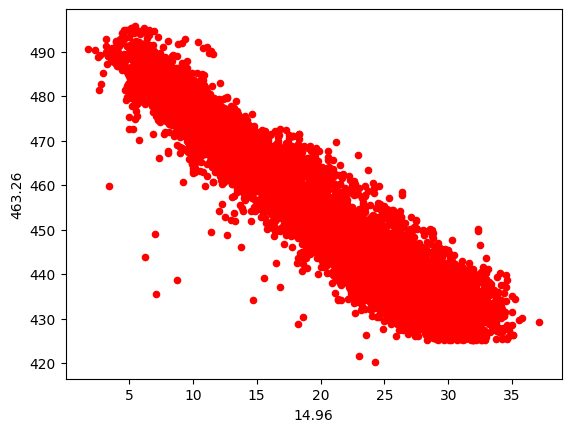

In [62]:
data.plot(kind='scatter',x='14.96',y='463.26',color='r')

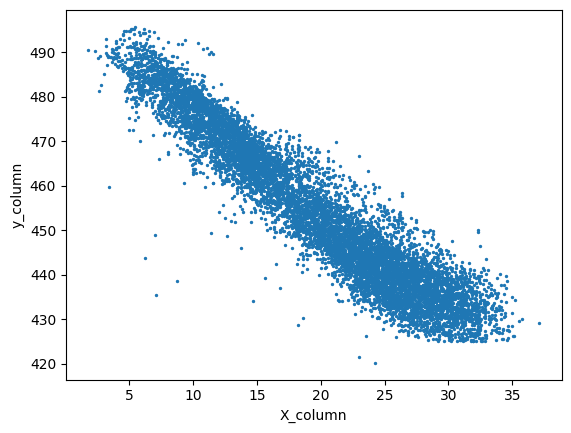

In [63]:
plt.scatter(data["14.96"], data["463.26"],s=2)
plt.xlabel("X_column")
plt.ylabel("y_column")
plt.show()

In [64]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
X = data[["14.96"]]
y = data["463.26"]

split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [75]:
print(X_train.head())
print(y_train.head())

print(X_train.isnull().sum())
print(y_train.isnull().sum())

print(X_train.dtypes)
print(y_train.dtype)

print(np.min(X_train.values), np.max(X_train.values))
print(np.min(y_train.values), np.max(y_train.values))

   14.96
0  13.16
1  28.26
2  27.98
3  28.64
4  31.12
0    468.40
1    436.31
2    440.68
3    434.40
4    427.06
Name: 463.26, dtype: float64
14.96    0
dtype: int64
0
14.96    float64
dtype: object
float64
1.81 35.56
421.57 495.76


In [76]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [77]:
mean_x = X_train.mean()
std_x = X_train.std()

print(mean_x)
print(std_x)

14.96    19.611121
dtype: float64
14.96    7.452183
dtype: float64


In [65]:
class SimpleLinearRegression:
    def __init__(self):
        self.m=0
        self.b=0
    def fit(self,X,y):
        X=np.array(X).flatten()
        y=np.array(y)
        n=len(X)
        
        mean_x=np.mean(X)
        mean_y=np.mean(y)
        numerator=np.sum((X-mean_x)*(y-mean_y))
        denominator=np.sum((X-mean_x)**2)
        self.m=numerator/denominator
        self.b=mean_y-self.m*mean_x
        
    def predict(self,X):
        X=np.array(X).flatten()
        return self.m*X+self.b

In [85]:
import numpy as np

class SimpleLinearRegressionGD:
    def __init__(self, learning_rate=0.0001, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0.0
        self.b = 0.0
        self.train_errors = []
        self.val_errors = []

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        X_train = np.array(X_train, dtype=float).flatten()
        y_train = np.array(y_train, dtype=float).flatten()

        if X_val is not None and y_val is not None:
            X_val = np.array(X_val, dtype=float).flatten()
            y_val = np.array(y_val, dtype=float).flatten()

        n = len(X_train)

        for i in range(self.epochs):
            y_pred = self.m * X_train + self.b

            dm = (-2 / n) * np.sum(X_train * (y_train - y_pred))
            db = (-2 / n) * np.sum(y_train - y_pred)

            self.m -= self.learning_rate * dm
            self.b -= self.learning_rate * db

            train_loss = np.mean((y_train - y_pred) ** 2)
            self.train_errors.append(train_loss)

            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_loss = np.mean((y_val - y_val_pred) ** 2)
                self.val_errors.append(val_loss)

    def predict(self, X):
        X = np.array(X, dtype=float).flatten()
        return self.m * X + self.b

In [67]:
print(SimpleLinearRegressionGD.__init__)

<function SimpleLinearRegressionGD.__init__ at 0x7694a33e3880>


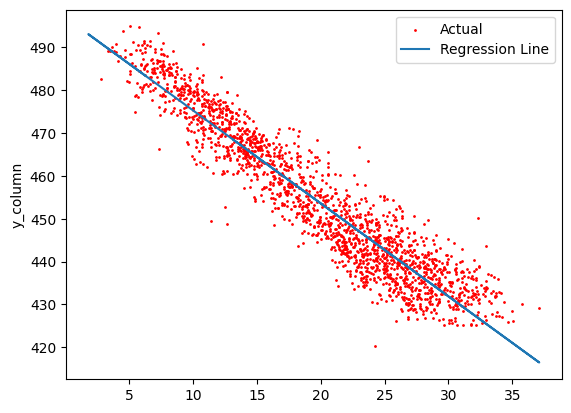

In [68]:
model=SimpleLinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
plt.scatter(X_test, y_test, color='red',s=1, label='Actual')
line_x = X.values.flatten()
line_y = model.predict(line_x)
plt.plot(line_x, line_y, label="Regression Line")
plt.ylabel("y_column")
plt.legend()
plt.show()

[468.43563419 435.6600779  436.26783656 ... 437.50505954 464.94102189
 483.36913268]


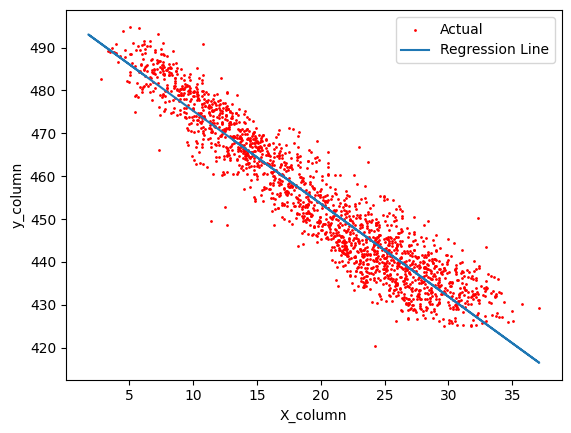

In [83]:
model2=SimpleLinearRegressionGD(learning_rate=0.001,epochs=100000)
model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
plt.scatter(X_test, y_test, color='red',s=1, label='Actual')
line_x = X.values.flatten()
line_y = model2.predict(line_x)
print(line_y)
plt.plot(line_x, line_y, label="Regression Line")
plt.ylabel("y_column")
plt.xlabel("X_column")
plt.legend()
plt.show()

# model2 = SimpleLinearRegressionGD(learning_rate=0.01, epochs=1000)

In [95]:
model = SimpleLinearRegressionGD(learning_rate=0.0005, epochs=100000)
model.fit(X_train, y_train, X_test, y_test)

y_pred = model.predict(X_test)

print("Slope:", model.m)
print("Intercept:", model.b)
print("Predictions:", y_pred[:10])

Slope: -2.1704914944874516
Intercept: 496.99860517866557
Predictions: [450.61520194 444.42930118 443.75644882 460.33900384 455.62903729
 436.91940061 471.34339571 476.57428022 464.22418361 474.5123133 ]


In [96]:
validation_error = np.mean((np.array(y_test).flatten() - y_pred) ** 2)
print("Validation Error (MSE):", validation_error)

Validation Error (MSE): 31.059671729910225


In [97]:
train_pred = model.predict(X_train)
train_error = np.mean((np.array(y_train).flatten() - train_pred) ** 2)
print("Training Error (MSE):", train_error)

Training Error (MSE): 29.028695893524446


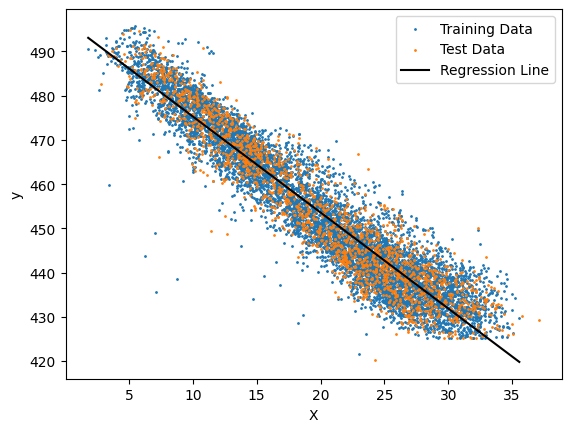

In [105]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, label="Training Data",s=1)
plt.scatter(X_test, y_test, label="Test Data",s=1)

x_line = np.array(X_train, dtype=float).flatten()
x_line = np.sort(x_line)

y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Regression Line",color='black')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

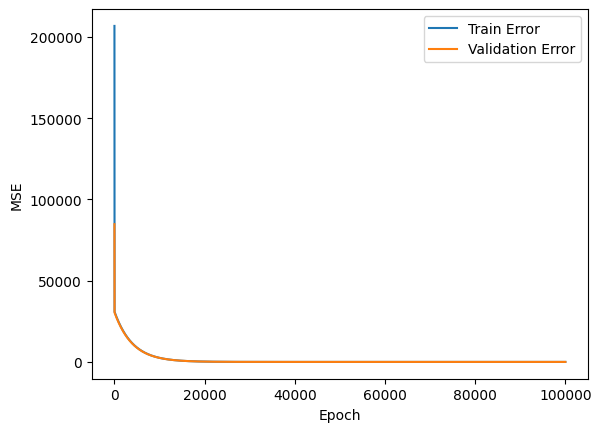

In [99]:
plt.plot(model.train_errors, label="Train Error")
plt.plot(model.val_errors, label="Validation Error")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()